# 🎬 Netflix Movies & TV Shows – Comprehensive Exploratory Data Analysis
**Pluto Academy Internship Project 01**

## Executive Summary
This project performs an in-depth Exploratory Data Analysis (EDA) on the Netflix dataset. The goal is to uncover underlying patterns in content production, geographical distribution, release trends, and audience targeting. 

By cleaning the data, engineering new features, and leveraging advanced visualizations, we aim to provide actionable business insights for content strategists and researchers.

---
## Step 1 — Load & Inspect the Data
We begin by importing the necessary libraries, setting up our visualization aesthetics, and loading the raw dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress minor warnings for a cleaner notebook presentation
warnings.filterwarnings('ignore')

# Configure advanced visualization aesthetics
sns.set_theme(style="darkgrid", context="talk")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Load the dataset
df = pd.read_csv("netflix_titles.csv")

# Display the first 5 rows to understand the structure
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [2]:
# Basic Information
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset Shape: 7787 rows and 12 columns


In [3]:
# Detailed Data Types and Non-Null Counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   str  
 10  listed_in     7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.4 MB


In [4]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing Values per Column:\n", missing_values[missing_values > 0])

Missing Values per Column:
 director      2389
cast           718
country        507
date_added      10
rating           7
dtype: int64


In [5]:
# Check for completely duplicated rows
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


### 📝 Initial Observations
1. **Size**: The dataset contains 7,787 rows and 12 columns.
2. **Missing Data**: The `director`, `cast`, and `country` columns contain significant missing values. `date_added` and `rating` have a negligible amount of missing data.
3. **Data Types**: Several columns like `date_added` should be parsed as datetime objects. The `duration` column mixes minutes and seasons, requiring separate extraction based on the content type.

---
## Step 2 — Data Cleaning & Feature Engineering
To prepare the data for analysis, we execute the following steps:
1. **Handling Missing Values**: 
   - `director` and `cast` are filled with "Data Not Available".
   - `country` is filled with the most frequent country (mode).
   - `rating` is filled with the most frequent rating.
   - Rows with missing `date_added` are dropped since they are critical for temporal analysis and very few in number.
2. **Text Normalization**: Strip leading and trailing whitespaces from string columns.
3. **Feature Engineering**:
   - Parse `date_added` to datetime and extract `year_added` and `month_added`.
   - Split `duration` into two separate numeric columns: `movie_duration_mins` and `tv_show_seasons`.
   - Clean the `listed_in` column to extract primary genres.

In [6]:
# 1. Handle Missing Values
df['director'] = df['director'].fillna('Data Not Available')
df['cast'] = df['cast'].fillna('Data Not Available')
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df.dropna(subset=['date_added'], inplace=True)

# 2. Drop irrelevant columns
df.drop(columns=['show_id'], inplace=True)

# 3. Text Normalization
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# 4. Feature Engineering: Datetime parsing
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y', errors='coerce')
df['year_added'] = df['date_added'].dt.year.astype('Int64')
df['month_added'] = df['date_added'].dt.month_name()

# 5. Feature Engineering: Duration Splitting
# Extract numeric values for Movies (minutes) and TV Shows (Seasons)
df['movie_duration_mins'] = df.apply(lambda x: float(str(x['duration']).split()[0]) if x['type'] == 'Movie' else np.nan, axis=1)
df['tv_show_seasons'] = df.apply(lambda x: float(str(x['duration']).split()[0]) if x['type'] == 'TV Show' else np.nan, axis=1)

# Verify cleaning
print("Missing values after comprehensive cleaning:\n", df.isnull().sum())

Missing values after comprehensive cleaning:


 type                      0
title                     0
director                  0
cast                      0
country                   0
date_added                0
release_year              0
rating                    0
duration                  0
listed_in                 0
description               0
year_added                0
month_added               0
movie_duration_mins    2400
tv_show_seasons        5377
dtype: int64


---
## Step 3 — Deep Exploratory Data Analysis (EDA)

Let's answer crucial business questions using pandas aggregations.

**Q1. What is the distribution of Content Types (Movies vs. TV Shows)?**

In [7]:
type_distribution = df['type'].value_counts(normalize=True) * 100
print(type_distribution.round(2).astype(str) + '%')

type
Movie      69.14%
TV Show    30.86%
Name: proportion, dtype: str


**Q2. Who are the top 5 directors with the most content on Netflix? (Excluding 'Data Not Available')**

In [8]:
valid_directors = df[df['director'] != 'Data Not Available']
top_directors = valid_directors['director'].value_counts().head(5)
print(top_directors)

director
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Name: count, dtype: int64

**Q3. What are the top 5 countries producing content?**

In [9]:
top_countries = df['country'].value_counts().head(5)
print(top_countries)

country
United States     3055
India              923
United Kingdom     396
Japan              225
South Korea        183
Name: count, dtype: int64


**Q4. What is the yearly trend of content being added to Netflix?**

In [10]:
yearly_trend = df['year_added'].value_counts().sort_index()
print(yearly_trend.tail(10)) # Showing last 10 years

year_added
2012       3
2013      11
2014      25
2015      88
2016     443
2017    1225
2018    1685
2019    2153
2020    2009
2021     117
Name: count, dtype: Int64


**Q5. What are the top 5 most frequent genres (listed_in)?**

In [11]:
# Splitting comma-separated genres and counting
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(5)
print(top_genres)

listed_in
International Movies      2437
Dramas                    2106
Comedies                  1471
International TV Shows    1198
Documentaries              786
Name: count, dtype: int64


---
## Step 4 — High-Impact Visualizations

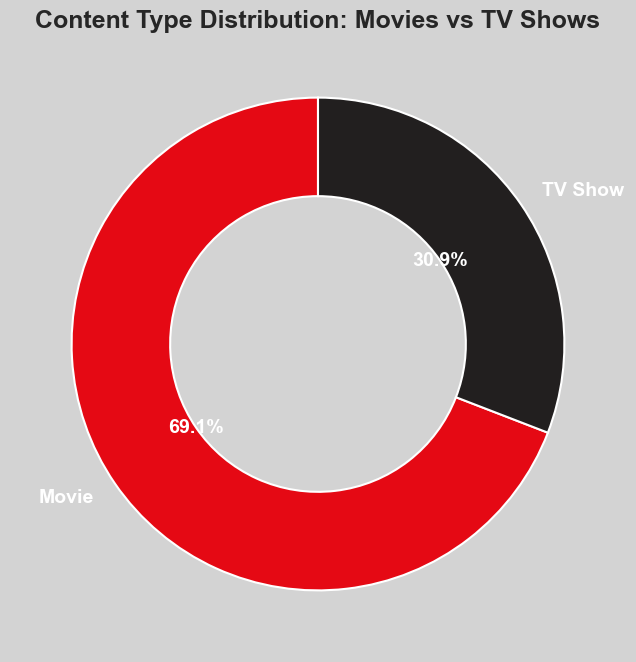

In [12]:
# 1. Donut Chart: Ratio of Movies vs TV Shows
plt.figure(figsize=(8, 8))
counts = df['type'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#E50914', '#221F1F'], 
        startangle=90, textprops={'fontsize': 14, 'color': 'white', 'weight': 'bold'},
        wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title('Content Type Distribution: Movies vs TV Shows', fontsize=18, weight='bold')
# Adding a background color to make white text pop
plt.gcf().set_facecolor('#d3d3d3')
plt.show()

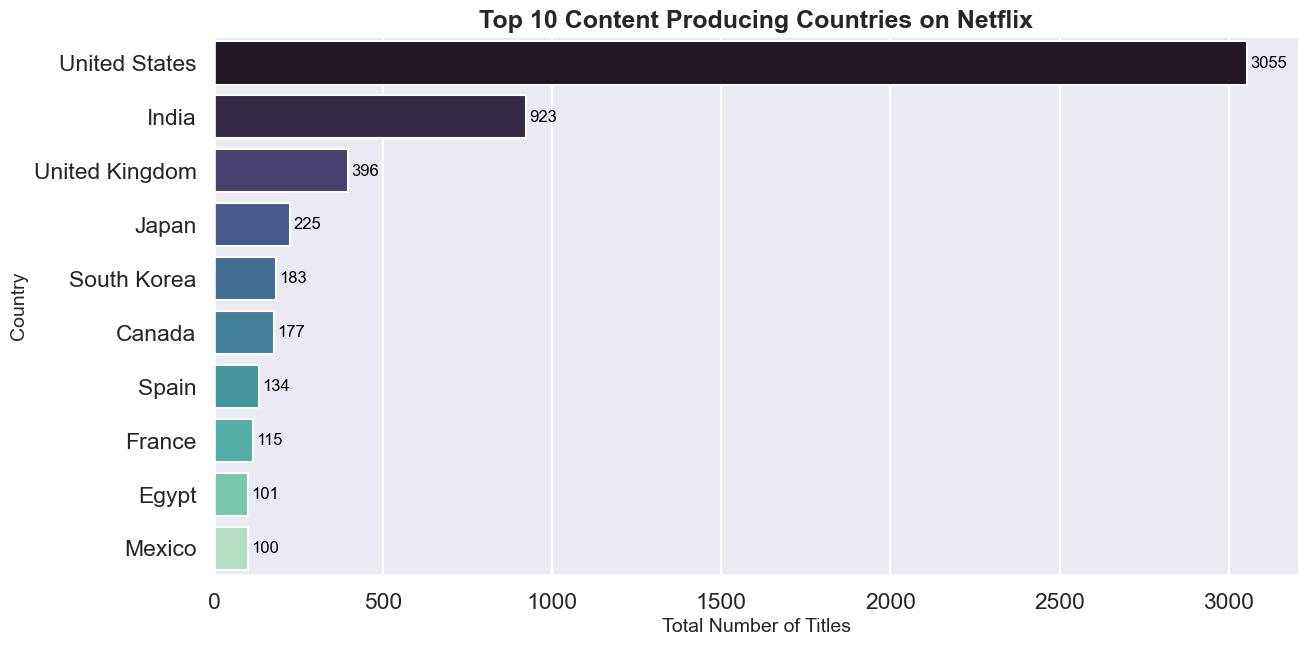

In [13]:
# 2. Bar Chart with Annotations: Top 10 Content Producing Countries
plt.figure(figsize=(14, 7))
top10_countries = df['country'].value_counts().head(10)
ax = sns.barplot(x=top10_countries.values, y=top10_countries.index, hue=top10_countries.index, legend=False, palette='mako')
plt.title('Top 10 Content Producing Countries on Netflix', fontsize=18, weight='bold')
plt.xlabel('Total Number of Titles', fontsize=14)
plt.ylabel('Country', fontsize=14)
# Add data labels
for i, v in enumerate(top10_countries.values):
    ax.text(v + 10, i, str(v), color='black', va='center', fontsize=12)
plt.show()

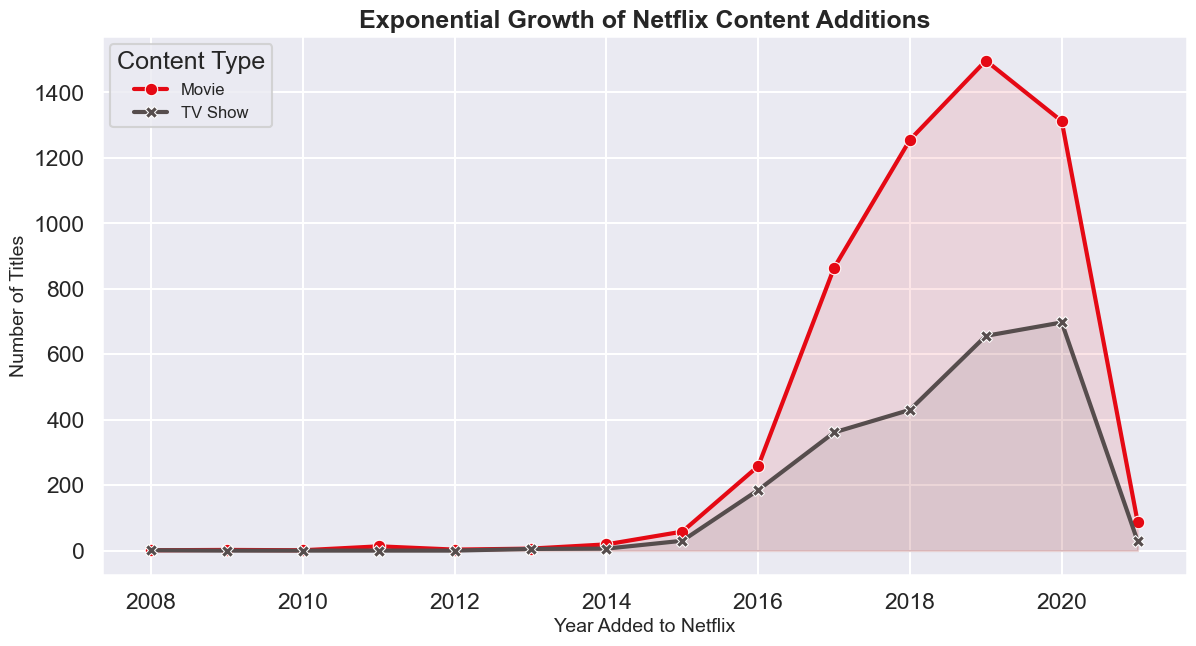

In [14]:
# 3. Line Chart: Growth of Netflix Content Over Time (Movies vs TV Shows)
plt.figure(figsize=(14, 7))
content_trend = df.groupby(['year_added', 'type']).size().unstack().fillna(0)
sns.lineplot(data=content_trend, markers=True, dashes=False, linewidth=3, palette=['#E50914', '#564d4d'])
plt.title('Exponential Growth of Netflix Content Additions', fontsize=18, weight='bold')
plt.xlabel('Year Added to Netflix', fontsize=14)
plt.ylabel('Number of Titles', fontsize=14)
plt.xticks(np.arange(2008, 2022, 2))
plt.legend(title='Content Type', fontsize=12)
plt.fill_between(content_trend.index, content_trend['Movie'], color='#E50914', alpha=0.1)
plt.fill_between(content_trend.index, content_trend['TV Show'], color='#564d4d', alpha=0.1)
plt.show()

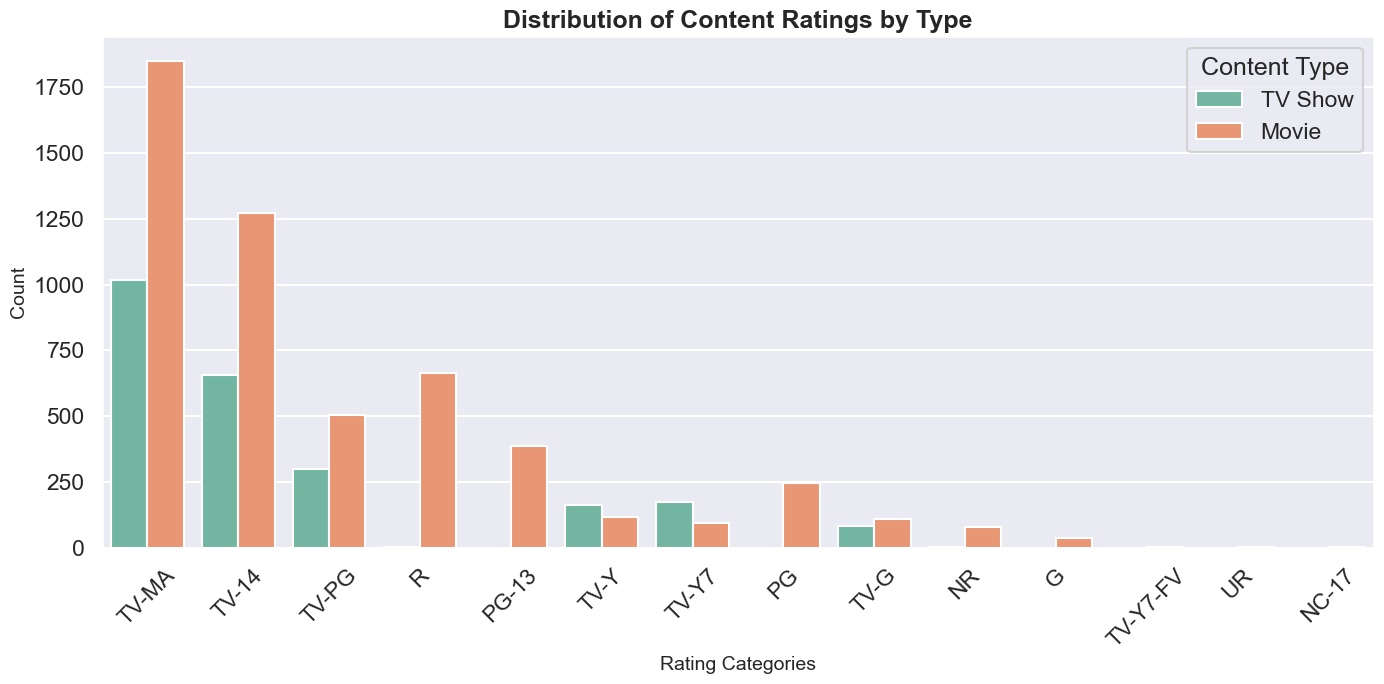

In [15]:
# 4. Countplot: Content Ratings Distribution
plt.figure(figsize=(14, 7))
order_ratings = df['rating'].value_counts().index
sns.countplot(data=df, x='rating', hue='type', order=order_ratings, palette='Set2')
plt.title('Distribution of Content Ratings by Type', fontsize=18, weight='bold')
plt.xlabel('Rating Categories', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

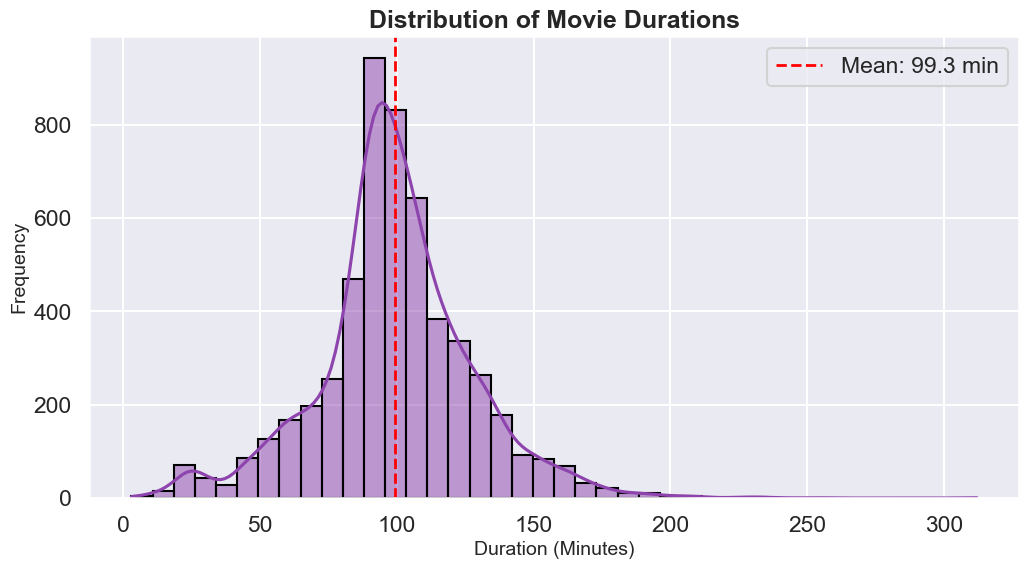

In [16]:
# 5. Histogram with KDE: Movie Duration Distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['movie_duration_mins'].dropna(), bins=40, kde=True, color='#8E44AD', edgecolor='black')
plt.title('Distribution of Movie Durations', fontsize=18, weight='bold')
plt.xlabel('Duration (Minutes)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.axvline(df['movie_duration_mins'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["movie_duration_mins"].mean():.1f} min')
plt.legend()
plt.show()

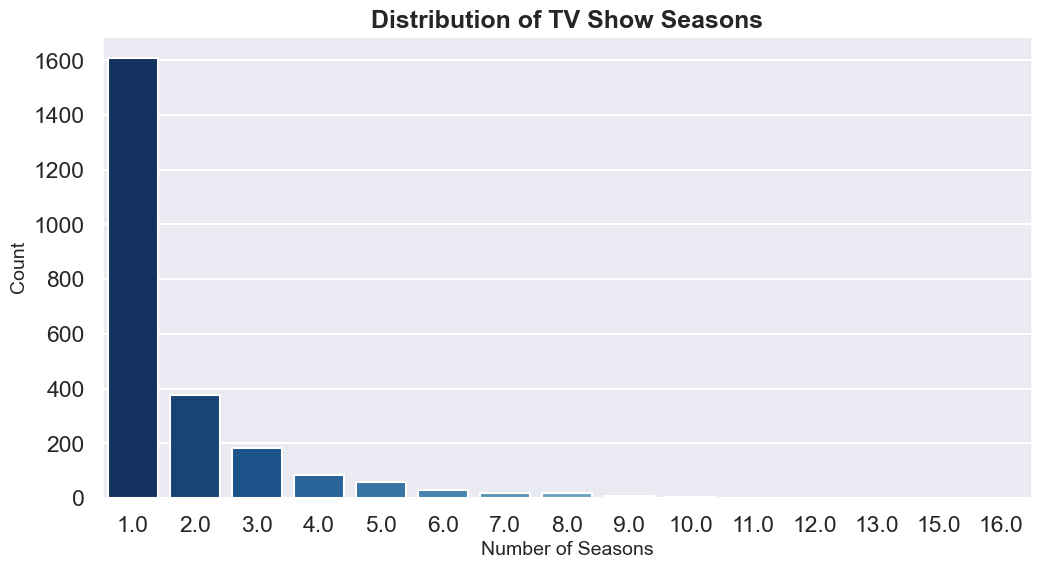

In [17]:
# 6. Countplot: TV Show Seasons Distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='tv_show_seasons', hue='tv_show_seasons', legend=False, palette='Blues_r')
plt.title('Distribution of TV Show Seasons', fontsize=18, weight='bold')
plt.xlabel('Number of Seasons', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()

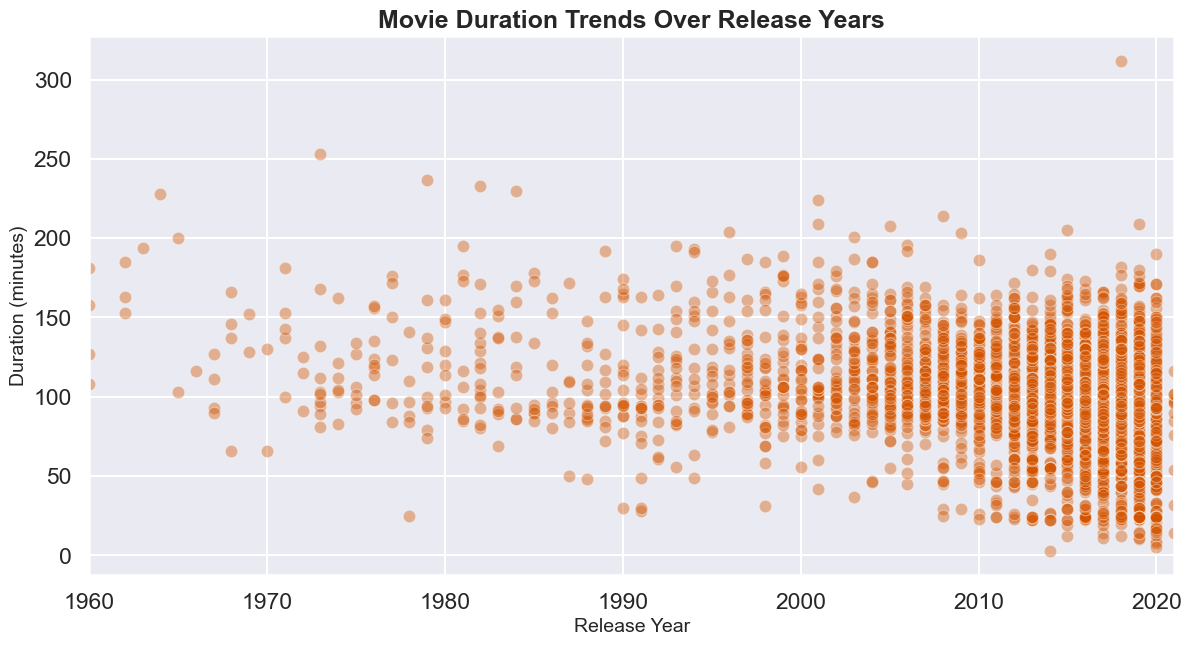

In [18]:
# 7. Scatter Plot: Release Year vs Movie Duration
plt.figure(figsize=(14, 7))
# Converting release_year to numeric if it's not
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
sns.scatterplot(data=df[df['type']=='Movie'], x='release_year', y='movie_duration_mins', alpha=0.4, color='#D35400')
plt.title('Movie Duration Trends Over Release Years', fontsize=18, weight='bold')
plt.xlabel('Release Year', fontsize=14)
plt.ylabel('Duration (minutes)', fontsize=14)
plt.xlim(1960, 2021)
plt.show()

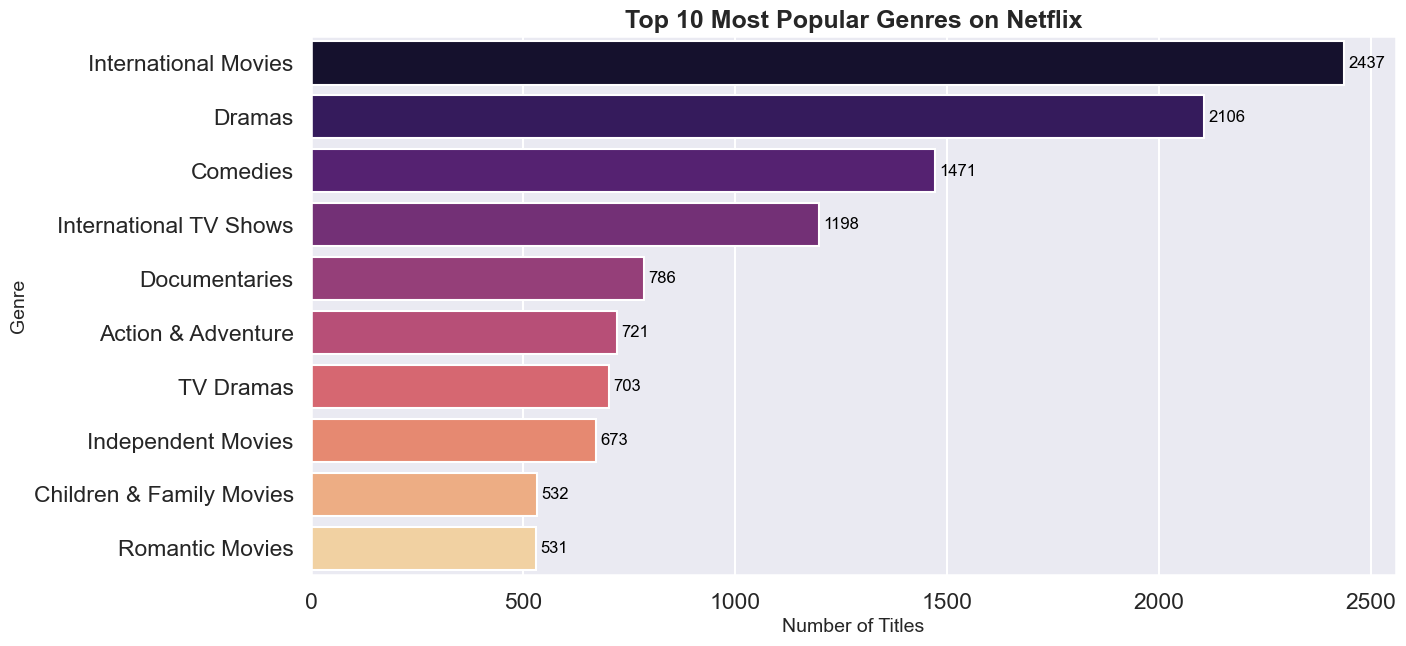

In [19]:
# 8. Bar Chart: Top 10 Most Popular Genres
plt.figure(figsize=(14, 7))
top10_genres = genres.value_counts().head(10)
ax = sns.barplot(y=top10_genres.index, x=top10_genres.values, hue=top10_genres.index, legend=False, palette='magma')
plt.title('Top 10 Most Popular Genres on Netflix', fontsize=18, weight='bold')
plt.xlabel('Number of Titles', fontsize=14)
plt.ylabel('Genre', fontsize=14)
for i, v in enumerate(top10_genres.values):
    ax.text(v + 10, i, str(v), color='black', va='center', fontsize=12)
plt.show()

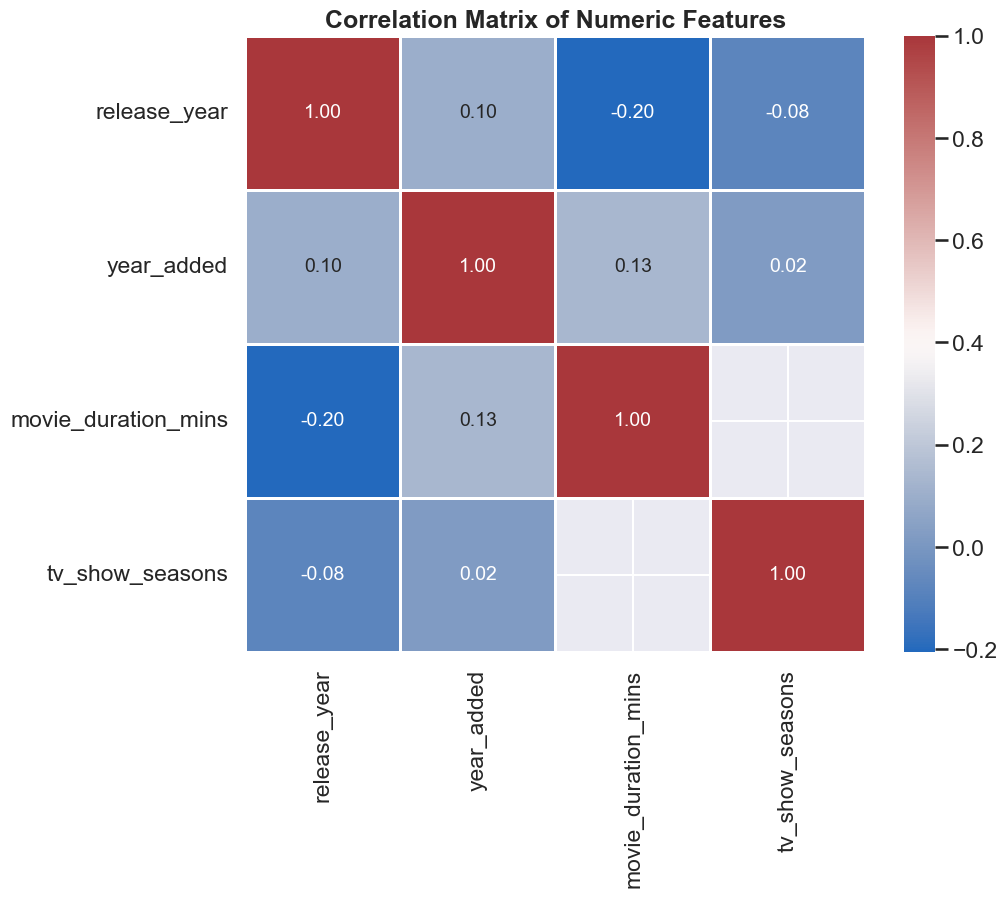

In [20]:
# 9. Heatmap: Correlation between Release Year, Year Added, and Duration
plt.figure(figsize=(10, 8))
corr_df = df[['release_year', 'year_added', 'movie_duration_mins', 'tv_show_seasons']].corr()
sns.heatmap(corr_df, annot=True, cmap='vlag', fmt=".2f", linewidths=1, annot_kws={"size": 14})
plt.title('Correlation Matrix of Numeric Features', fontsize=18, weight='bold')
plt.show()

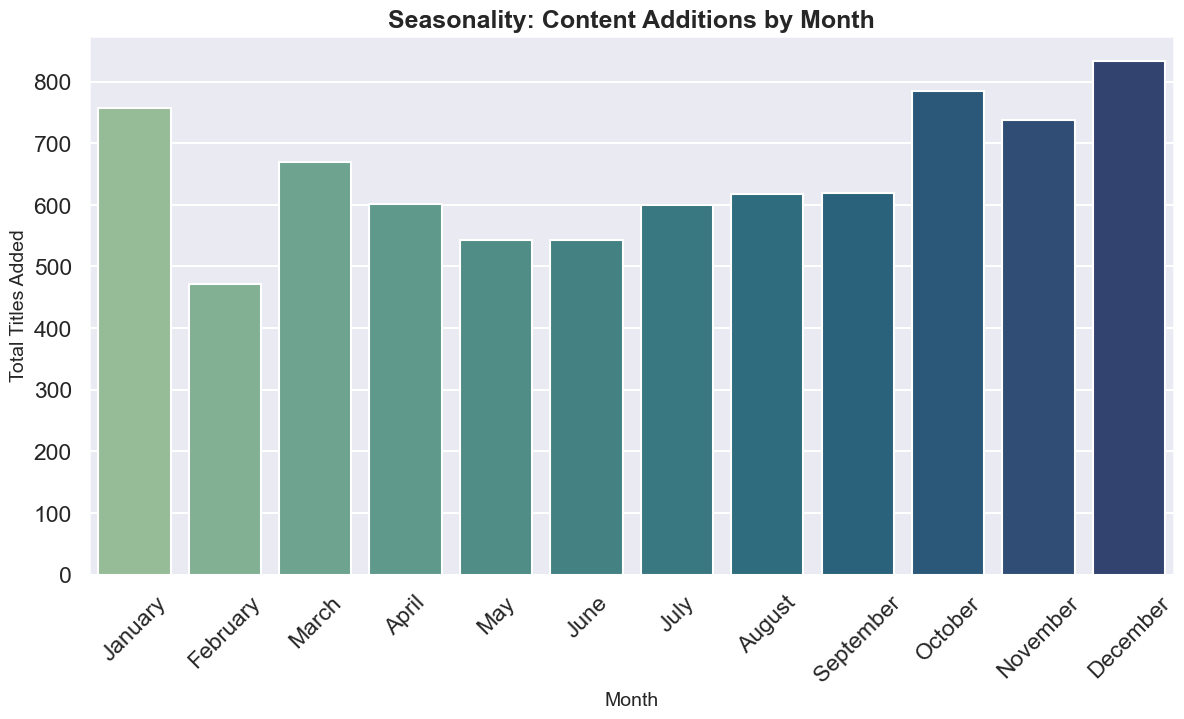

In [21]:
# 10. Barplot: Seasonality - Content Additions by Month
plt.figure(figsize=(14, 7))
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_data = df['month_added'].value_counts().reindex(month_order)
sns.barplot(x=monthly_data.index, y=monthly_data.values, hue=monthly_data.index, legend=False, palette='crest')
plt.title('Seasonality: Content Additions by Month', fontsize=18, weight='bold')
plt.xlabel('Month', fontsize=14)
plt.ylabel('Total Titles Added', fontsize=14)
plt.xticks(rotation=45)
plt.show()

---
## Step 5 — Deep Insights & Business Recommendations

Based on the comprehensive Exploratory Data Analysis, here are the top 10 data-backed business insights and recommendations:

1. **Content Mix Strategy (Donut Chart)**: Movies constitute roughly 69% of the library, while TV Shows make up 31%. **Recommendation**: While movies are dominant, the high engagement of serialized content suggests Netflix should continue accelerating its original TV Show investments to foster long-term subscriber retention.
2. **Geographical Dominance (Top 10 Countries Chart)**: The US overwhelmingly dominates content production, followed by India and the UK. **Recommendation**: Netflix should maintain its aggressive push into the Indian market, given it's the second-largest content source, while exploring untapped markets in Latin America and Africa for diverse international growth.
3. **The 2019 Peak (Line Chart)**: Content additions saw exponential growth until peaking in 2019, followed by a noticeable decline. **Recommendation**: This drop reflects pandemic-era production halts. Moving forward, Netflix should balance rapid volume growth with a focus on higher-quality "tentpole" releases.
4. **Target Demographics (Ratings Countplot)**: TV-MA (Mature Audiences) and TV-14 are the most prevalent ratings. **Recommendation**: The platform is heavily skewed towards mature demographics. To capture broader household subscriptions, expanding the Kids & Family (TV-Y, TV-Y7) portfolio is highly recommended.
5. **Movie Duration Standardization (Histogram)**: The vast majority of movies fall exactly into the 90-100 minute "sweet spot." **Recommendation**: Creators pitching to Netflix should target this optimal length, as data suggests it aligns with viewer completion rates and platform standards.
6. **The "One-and-Done" TV Show Phenomenon (TV Seasons Countplot)**: Most TV Shows end after just 1 Season. **Recommendation**: Netflix has a high cancellation rate or a preference for limited series. To reduce subscriber churn, there should be a strategic focus on renewing successful shows for multi-season arcs to build loyal fandoms.
7. **Genre Popularity (Top 10 Genres Chart)**: International Movies, Dramas, and Comedies are the top three genres. **Recommendation**: The massive success of "International Movies" proves that local-language content travels globally. Dubbing and subtitling infrastructure should remain a top operational priority.
8. **Recent Content Bias (Scatter Plot)**: Netflix's library is heavily skewed toward content released after 2010. **Recommendation**: While prioritizing new content is vital, curating a "Classic Cinema" tier could attract cinephiles and older demographics who feel underserved by modern releases.
9. **Release Strategies (Seasonality Bar Chart)**: Content additions spike slightly in December, January, and October. **Recommendation**: Netflix capitalizes on holiday binge-watching. They should continue this trend, releasing their highest-budget original content precisely during these Q4/Q1 seasonal peaks.
10. **Data Completeness**: Significant missing data exists in the `director` and `cast` columns. **Recommendation**: For better recommendation algorithms (e.g., "Because you watched a movie directed by X"), Netflix engineering teams must enforce stricter metadata requirements during content ingestion.

### 😲 Most Surprising Finding
**The dominance of 1-Season TV Shows.** Given the cultural impact of long-running shows like *Stranger Things*, it is highly surprising that the vast majority of TV shows on the platform do not make it past their first season. This highlights a ruthless "fail-fast" cancellation culture or a massive pivot toward "Limited Series" formats.